# Etapa 3 — Identificar Padrões Nacionais
## Análise de Consistência e Dispersão

## Contexto

Nas etapas anteriores calculamos as taxas de execução e comparamos as capitais com estatística descritiva. Agora vamos identificar padrões nacionais — quais capitais estão consistentemente acima da média e qual função é mais problemática.

## Objetivo

Identificar:

- **Quais capitais** estão consistentemente acima da média em várias funções
- **Qual função** é mais problemática nacionalmente
- **Existe função** onde todas as capitais se comportam parecido

## Perguntas que esta etapa responde

1. **"Quais capitais estão consistentemente acima da média em várias funções?"**
2. **"Qual função é mais problemática nacionalmente?"**
3. **"Existe uma função onde todas as capitais se comportam parecido?"**

## Fórmulas

**Classificação Acima/Abaixo da Média:**
$$Se\ TaxaExecucao(C,F) > Media(F) \rightarrow "Acima\ da\ média"$$

**Coeficiente de Variação (CV):**
$$CV(F) = \frac{DP(F)}{Media(F)} \times 100$$

- CV < 15%: Baixa dispersão (homogênea)
- 15% <= CV < 30%: Dispersão moderada
- CV >= 30%: Alta dispersão (heterogênea)

In [2]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Adiciona a raiz do projeto ao sys.path
sys.path.insert(0, str(Path.cwd().parent))

## 1. Carregar Dados das Etapas Anteriores

In [3]:
# Carregar dados
pasta_processados = Path.cwd().parent / 'data' / 'processed'

df_taxa_funcao = pd.read_parquet(pasta_processados / 'etapa1_taxa_por_funcao.parquet')
df_taxa_geral = pd.read_parquet(pasta_processados / 'etapa1_taxa_geral.parquet')
df_estatisticas = pd.read_parquet(pasta_processados / 'etapa2_estatisticas_por_funcao.parquet')

print(f'Taxa por funcao: {len(df_taxa_funcao)} registros')
print(f'Taxa geral: {len(df_taxa_geral)} capitais')
print(f'Estatisticas: {len(df_estatisticas)} funcoes')

Taxa por funcao: 541 registros
Taxa geral: 26 capitais
Estatisticas: 27 funcoes


## 2. Classificar Capitais Acima/Abaixo da Média

Para cada função, vamos classificar se cada capital está acima ou abaixo da média nacional.

In [4]:
# Criar dicionario de medias por funcao
medias_por_funcao = df_estatisticas.set_index('Funcao')['Media'].to_dict()

# Classificar cada registro
df_taxa_funcao['Media_Funcao'] = df_taxa_funcao['Funcao'].map(medias_por_funcao)
df_taxa_funcao['Classificacao'] = df_taxa_funcao.apply(
    lambda row: 'Acima da media' if row['Taxa_Execucao'] > row['Media_Funcao'] else 'Abaixo da media',
    axis=1
)

print('=== CLASSIFICACAO POR FUNCAO ===')
print(f'\nTotal de registros: {len(df_taxa_funcao)}')
print(f'\nDistribuicao:')
print(df_taxa_funcao['Classificacao'].value_counts())

=== CLASSIFICACAO POR FUNCAO ===

Total de registros: 541

Distribuicao:
Classificacao
Acima da media     338
Abaixo da media    203
Name: count, dtype: int64


### Interpretação

A distribuição mostra quantas capitais estão acima e abaixo da média em cada função. Se há muitas capitais abaixo da média, a função é mais problemática nacionalmente.

## 3. Identificar Capitais Consistentemente Acima da Média

Vamos contar em quantas funções cada capital está acima da média.

In [5]:
# Contar funcoes acima da media por capital
acima_por_capital = df_taxa_funcao[df_taxa_funcao['Classificacao'] == 'Acima da media']
contagem = acima_por_capital.groupby('Instituição').size().reset_index(name='Funcoes_Acima_Media')

# Total de funcoes por capital
total_funcoes_por_capital = df_taxa_funcao.groupby('Instituição').size().reset_index(name='Total_Funcoes')

# Juntar
df_consistencia = contagem.merge(total_funcoes_por_capital, on='Instituição')
df_consistencia['Percentual_Acima'] = (df_consistencia['Funcoes_Acima_Media'] / df_consistencia['Total_Funcoes'] * 100).round(2)

# Ordenar
df_consistencia = df_consistencia.sort_values('Percentual_Acima', ascending=False)

print('=== CAPITAIS MAIS CONSISTENTES ===')
print('(Acima da media em mais funcoes)\n')
df_consistencia.head(10)

=== CAPITAIS MAIS CONSISTENTES ===
(Acima da media em mais funcoes)



,Instituição,Funcoes_Acima_Media,Total_Funcoes,Percentual_Acima
8,Prefeitura Municipal de Fortaleza - CE,22,23,95.65
2,Prefeitura Municipal de Belém - PA,20,21,95.24
0,Prefeitura Municipal de Aracaju - SE,19,20,95.00
18,Prefeitura Municipal de Recife - PE,18,19,94.74
13,Prefeitura Municipal de Manaus - AM,19,21,90.48
9,Prefeitura Municipal de Goiânia - GO,18,22,81.82
5,Prefeitura Municipal de Cuiabá - MT,15,19,78.95
19,Prefeitura Municipal de Rio Branco - AC,16,21,76.19
15,Prefeitura Municipal de Palmas - TO,17,23,73.91
20,Prefeitura Municipal de Salvador - BA,17,23,73.91


### Interpretação

As capitais no topo estão acima da média em mais funções, indicando consistência na execução orçamentária.

## 4. Identificar Função Mais Problemática

A função mais problemática é aquela onde **mais capitais** estão abaixo da média.

In [6]:
# Contar capitais abaixo da media por funcao
abaixo_por_funcao = df_taxa_funcao[df_taxa_funcao['Classificacao'] == 'Abaixo da media']
contagem_funcao = abaixo_por_funcao.groupby('Funcao').size().reset_index(name='Capitais_Abaixo_Media')

# Total de capitais por funcao
total_capitais_por_funcao = df_taxa_funcao.groupby('Funcao').size().reset_index(name='Total_Capitais')

# Juntar
df_problema = contagem_funcao.merge(total_capitais_por_funcao, on='Funcao')
df_problema['Percentual_Abaixo'] = (df_problema['Capitais_Abaixo_Media'] / df_problema['Total_Capitais'] * 100).round(2)

# Ordenar
df_problema = df_problema.sort_values('Percentual_Abaixo', ascending=False)

print('=== FUNCOES MAIS PROBLEMATICAS ===')
print('(Mais capitais abaixo da media)\n')
df_problema

=== FUNCOES MAIS PROBLEMATICAS ===
(Mais capitais abaixo da media)



,Funcao,Capitais_Abaixo_Media,Total_Capitais,Percentual_Abaixo
4,05 - Defesa Nacional,2,3,66.67
3,04 - Administração,13,26,50.00
9,10 - Saúde,13,26,50.00
19,20 - Agricultura,8,16,50.00
22,24 - Comunicações,4,9,44.44
5,06 - Segurança Pública,11,25,44.00
0,01 - Legislativa,11,26,42.31
12,13 - Cultura,11,26,42.31
11,12 - Educação,11,26,42.31
21,23 - Comércio e Serviços,11,26,42.31


### Interpretação

A função no topo é a mais problemática — a maioria das capitais não consegue executar bem o orçamento nessa área.

## 5. Função Mais Homogênea e Mais Heterogênea

Vou usar os dados da etapa 2 para identificar.

In [7]:
# Funcao mais homogenea (menor CV)
mais_homogenea = df_estatisticas.sort_values('CV').iloc[0]

# Funcao mais heterogenea (maior CV)
mais_heterogenea = df_estatisticas.sort_values('CV', ascending=False).iloc[0]

print('=== ANALISE DE DISPERSAO ===')

print(f'\nMais HOMOGENEA (menor CV):')
print(f'  Funcao: {mais_homogenea["Funcao"]}')
print(f'  CV: {mais_homogenea["CV"]:.2f}%')
print(f'  Media: {mais_homogenea["Media"]:.2f}%')
print(f'  Todas as capitais se comportam parecido? SIM')

print(f'\nMais HETEROGENEA (maior CV):')
print(f'  Funcao: {mais_heterogenea["Funcao"]}')
print(f'  CV: {mais_heterogenea["CV"]:.2f}%')
print(f'  Media: {mais_heterogenea["Media"]:.2f}%')
print(f'  Grandes diferencas entre capitais? SIM')

=== ANALISE DE DISPERSAO ===

Mais HOMOGENEA (menor CV):
  Funcao: 09 - Previdência Social
  CV: 2.38%
  Media: 98.52%
  Todas as capitais se comportam parecido? SIM

Mais HETEROGENEA (maior CV):
  Funcao: 19 - Ciência e Tecnologia
  CV: 29.72%
  Media: 79.67%
  Grandes diferencas entre capitais? SIM


## 6. Scatter Plot: Taxa Geral vs Desvio Padrão

In [10]:
# Preparar dados para scatter plot
# Precisamos do desvio padrao das taxas anuais por capital
query_dp_anual = """
WITH taxa_anual AS (
    SELECT
        Instituição,
        UF,
        Ano,
        SUM(CASE WHEN Coluna = 'Despesas Pagas' THEN Valor ELSE 0 END) as Pago,
        SUM(CASE WHEN Coluna = 'Despesas Empenhadas' THEN Valor ELSE 0 END) as Empenhado
    FROM despesas_finbra
    WHERE ContaTipo = 'Função'
      AND Ano BETWEEN 2020 AND 2024
    GROUP BY Instituição, UF, Ano
)
SELECT
    Instituição,
    UF,
    AVG(CASE WHEN Empenhado > 0 THEN (Pago / Empenhado) * 100 ELSE NULL END) as Media_Anual,
    STDDEV(CASE WHEN Empenhado > 0 THEN (Pago / Empenhado) * 100 ELSE NULL END) as DP_Anual
FROM taxa_anual
GROUP BY Instituição, UF
"""

# Conectar ao DuckDB para esta consulta
from src.banco.conexao_duckdb import conectar
from src.utils.constantes import CAMINHO_DUCKDB

con = conectar(CAMINHO_DUCKDB)
df_dp_anual = con.execute(query_dp_anual).df()
con.close()

print(f'Dados anuais: {len(df_dp_anual)} capitais')
df_dp_anual.head()

Dados anuais: 26 capitais


,Instituição,UF,Media_Anual,DP_Anual
0,Prefeitura Municipal de Fortaleza - CE,CE,96.007705,1.752655
1,Prefeitura Municipal do Rio de Janeiro - RJ,RJ,89.007670,3.419685
2,Prefeitura Municipal de Aracaju - SE,SE,96.866855,1.859070
3,Prefeitura Municipal de Salvador - BA,BA,94.935358,2.329872
4,Prefeitura Municipal de São Luís - MA,MA,88.224857,1.383335


In [11]:
# Juntar com taxa geral
df_scatter = df_taxa_geral.merge(df_dp_anual, on=['Instituição', 'UF'])

# Extrair nomes das capitais
df_scatter['Capital'] = df_scatter['Instituição'].apply(
    lambda x: x.replace('Prefeitura Municipal de ', '').replace('Prefeitura Municipal do ', '').split(' - ')[0].strip()
)

# Identificar Maceio
df_scatter['Eh_Maceio'] = df_scatter['Capital'] == 'Maceió'

print(f'Dados para scatter: {len(df_scatter)} capitais')

Dados para scatter: 26 capitais


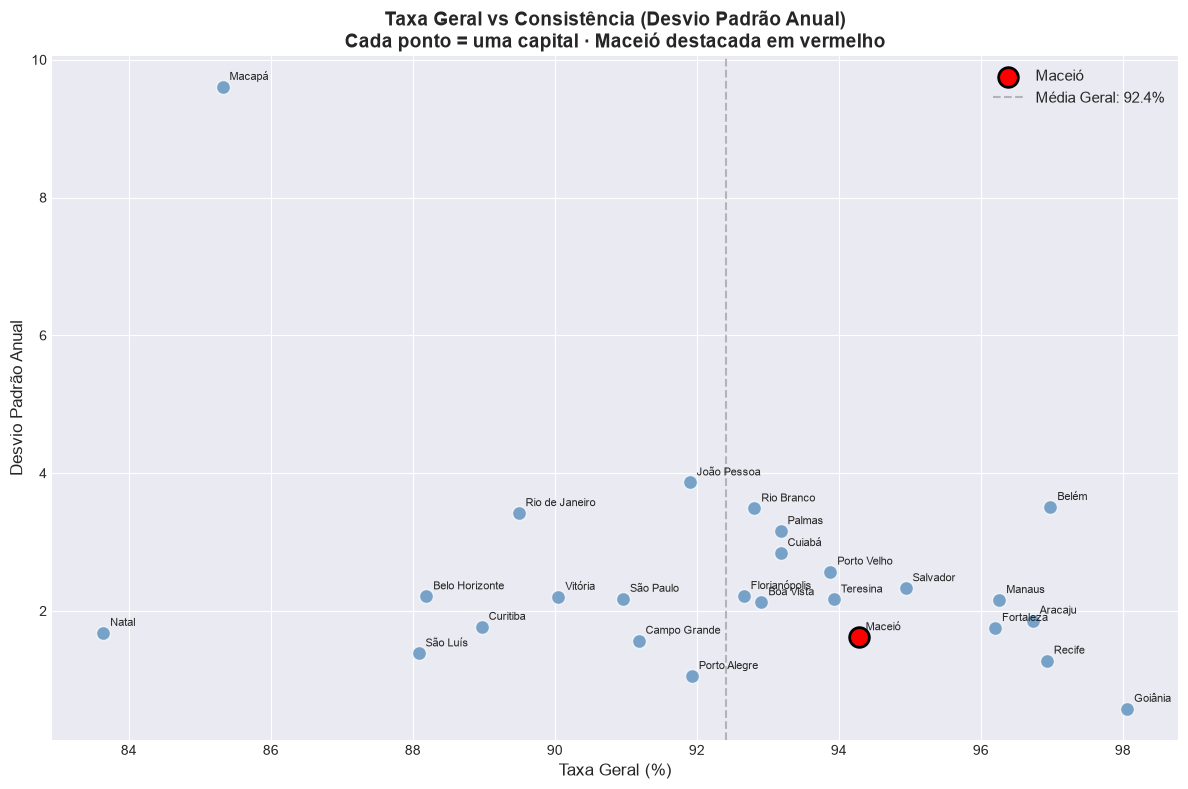

In [12]:
# Criar scatter plot
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(12, 8))

# Plotar pontos normais
df_normal = df_scatter[~df_scatter['Eh_Maceio']]
ax.scatter(df_normal['Taxa_Geral'], df_normal['DP_Anual'], 
           s=100, alpha=0.7, c='steelblue', edgecolors='white', linewidth=1)

# Plotar Maceio destacada
df_maceio = df_scatter[df_scatter['Eh_Maceio']]
ax.scatter(df_maceio['Taxa_Geral'], df_maceio['DP_Anual'], 
           s=200, c='red', edgecolors='black', linewidth=2, zorder=5, label='Maceió')

# Adicionar nomes das capitais
for _, row in df_scatter.iterrows():
    ax.annotate(row['Capital'], (row['Taxa_Geral'], row['DP_Anual']),
                textcoords='offset points', xytext=(5, 5), fontsize=8)

# Adicionar linhas de referencia
media_geral = df_scatter['Taxa_Geral'].mean()
ax.axvline(x=media_geral, color='gray', linestyle='--', alpha=0.5, label=f'Média Geral: {media_geral:.1f}%')

ax.set_xlabel('Taxa Geral (%)', fontsize=12)
ax.set_ylabel('Desvio Padrão Anual', fontsize=12)
ax.set_title('Taxa Geral vs Consistência (Desvio Padrão Anual)\n'
             'Cada ponto = uma capital · Maceió destacada em vermelho',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

### Interpretação do Gráfico

- **Eixo X**: Taxa Geral (eficiência orçamentária)
- **Eixo Y**: Desvio Padrão Anual (consistência)
- **Quanto mais à direita**: melhor execução
- **Quanto mais embaixo**: mais consistente

O ideal é estar **canto inferior direito** (alta taxa, baixo desvio).

## 7. Salvar Resultados

In [13]:
# Salvar resultados
df_consistencia.to_parquet(pasta_processados / 'etapa3_consistencia_capitais.parquet', index=False)
df_problema.to_parquet(pasta_processados / 'etapa3_funcoes_problematicas.parquet', index=False)

print('Arquivos salvos:')
print(f'  - {pasta_processados / "etapa3_consistencia_capitais.parquet"}')
print(f'  - {pasta_processados / "etapa3_funcoes_problematicas.parquet"}')

Arquivos salvos:
  - c:\Users\corre\OneDrive\Área de Trabalho\Desafio-Analista-de-Dados-Sefaz-Macei-\data\processed\etapa3_consistencia_capitais.parquet
  - c:\Users\corre\OneDrive\Área de Trabalho\Desafio-Analista-de-Dados-Sefaz-Macei-\data\processed\etapa3_funcoes_problematicas.parquet


In [ ]:
# Fechar conexao com o DuckDB
con.close()
print('Conexao com DuckDB fechada.')


## Conclusão da Etapa 3

### O que descobrimos:

1. **Capitais consistentes**: Quais estão acima da média em mais funções
2. **Funções problemáticas**: Onde mais capitais estão abaixo da média
3. **Homogeneidade**: Função onde todas as capitais se comportam parecido (menor CV)
4. **Heterogeneidade**: Função com maiores diferenças entre capitais (maior CV)
5. **Visualização**: Scatter plot mostrando relação entre eficiência e consistência

### Próxima etapa:

Na **Etapa 4**, vamos **selecionar estudos de caso** — a melhor capital, a pior e Maceió.